## IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
import os

In [2]:
# Create a folder for figures
os.makedirs("results/figures", exist_ok=True)

In [3]:
# Read HR Employee-Attrition Dataset
emp_dataset = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(emp_dataset.head())
print(emp_dataset.tail())
print(emp_dataset.info())
print(emp_dataset.describe())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [4]:
print(emp_dataset.isnull())


        Age  Attrition  BusinessTravel  DailyRate  Department  \
0     False      False           False      False       False   
1     False      False           False      False       False   
2     False      False           False      False       False   
3     False      False           False      False       False   
4     False      False           False      False       False   
...     ...        ...             ...        ...         ...   
1465  False      False           False      False       False   
1466  False      False           False      False       False   
1467  False      False           False      False       False   
1468  False      False           False      False       False   
1469  False      False           False      False       False   

      DistanceFromHome  Education  EducationField  EmployeeCount  \
0                False      False           False          False   
1                False      False           False          False   
2              

In [5]:
emp_dataset["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [6]:
emp_dataset.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
emp_dataset.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [8]:
# Dropping useless columns
emp_dataset.drop(columns=["EmployeeCount", "Over18", "StandardHours"], inplace=True)

In [9]:
# Dropping employee Number column
emp_dataset.drop(columns=["EmployeeNumber"], inplace=True)

In [10]:
emp_dataset.shape

(1470, 31)

In [11]:
# Converting Attrition to binary 0 or 1
emp_dataset["Attrition"] = emp_dataset["Attrition"].map({"Yes":1, "No":0})

In [12]:
# Verify that the conversion was successful
emp_dataset["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [13]:
# Identify categorical columns
emp_dataset.select_dtypes(include=["object"]).columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [14]:
# Apply one-hot encoding
emp_dataset = pd.get_dummies(emp_dataset, drop_first=True)

In [15]:
# Verify that the encoding worked
emp_dataset.select_dtypes(include=["object"]).columns

Index([], dtype='object')

In [16]:
emp_dataset.shape

(1470, 45)

In [17]:
# Check the Attrition
emp_dataset["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [18]:
# Feature scaling
from sklearn.preprocessing import StandardScaler
X = emp_dataset.drop("Attrition", axis=1)
y = emp_dataset["Attrition"]


## Train/Test Split

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
# Verify the split
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64
Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


## Train Logistic Regression 

In [21]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight="balanced", max_iter=5000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [22]:
# Make prediction
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [23]:
# Evaluate the model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294

[[192  55]
 [ 18  29]]
ROC-AUC: 0.7982599707123783


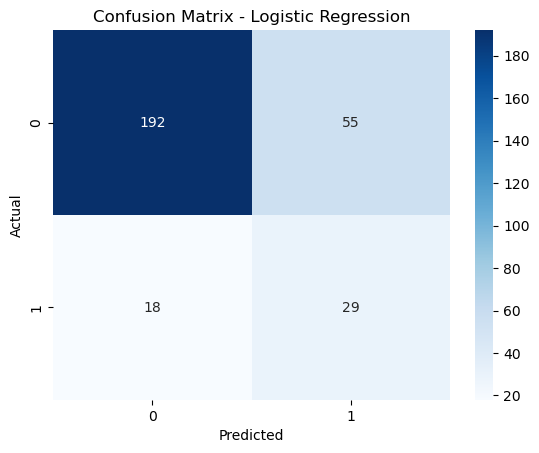

In [24]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.savefig("results/figures/logistic_confusion_matrix.png", bbox_inches="tight")
plt.show()

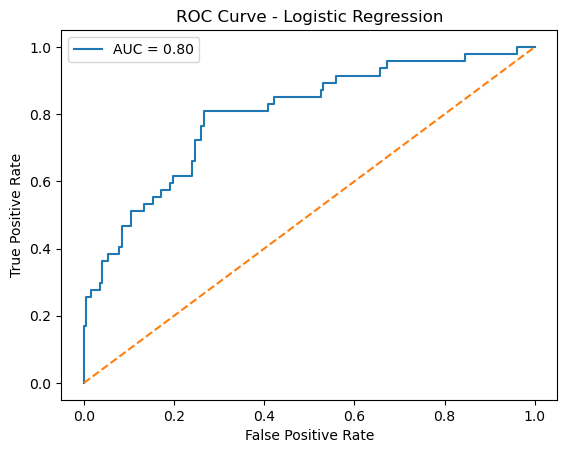

In [25]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.savefig("results/figures/logistic_roc_curve.png", bbox_inches="tight")
plt.show()

# TRAINING RANDOM FOREST

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators = 100, class_weight = "balanced", random_state = 42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
# Make prediction
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:,1]

In [28]:
# Evaluate the model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.8367346938775511
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294

[[242   5]
 [ 43   4]]
ROC-AUC: 0.7547161684899647


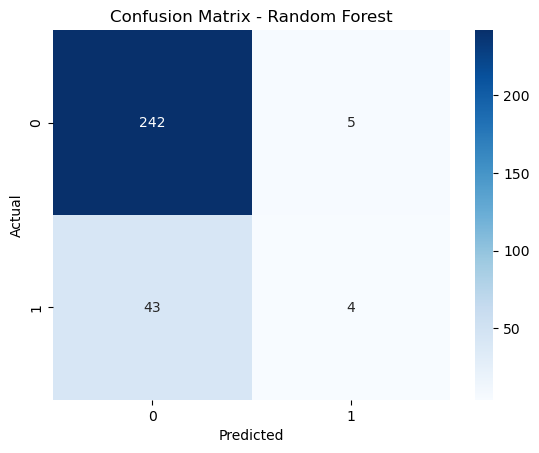

In [29]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.savefig("results/figures/RF_confusion_matrix.png", bbox_inches="tight")
plt.show()

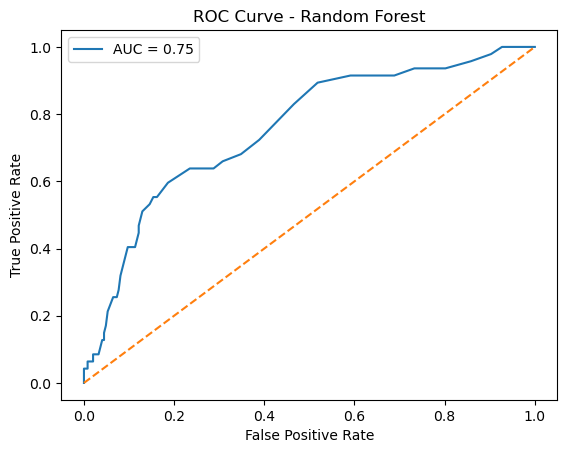

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.savefig("results/figures/RF_roc_curve.png", bbox_inches="tight")
plt.show()

# TRAINING XGBOOST

In [31]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(scale_pos_weight = 1233/237, # handle imbalance 
                          n_estimators = 200,
                          learning_rate = 0.05,
                          max_depth = 5,
                          random_state = 42
)
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [32]:
# Make prediction
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [33]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

Accuracy: 0.8401360544217688
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       247
           1       0.50      0.38      0.43        47

    accuracy                           0.84       294
   macro avg       0.69      0.66      0.67       294
weighted avg       0.83      0.84      0.83       294

[[229  18]
 [ 29  18]]
ROC-AUC: 0.7642346455336377


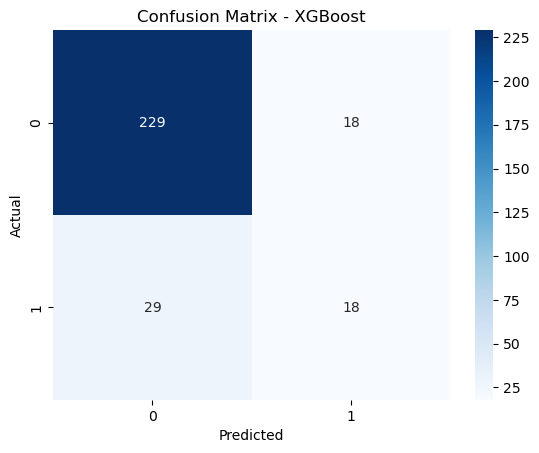

In [34]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.savefig("results/figures/XGBoost_confusion_matrix.png", bbox_inches="tight")
plt.show()

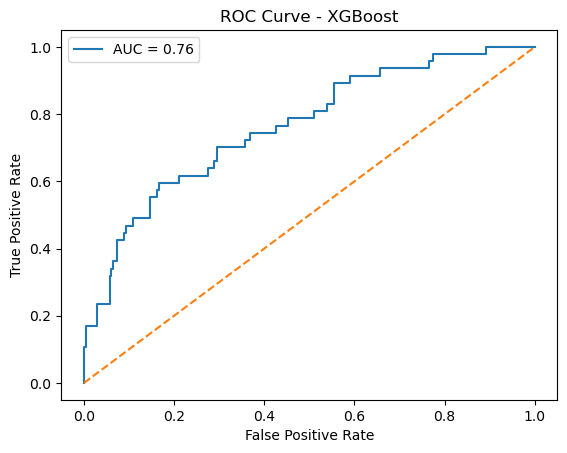

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba_xgb):.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.savefig("results/figures/XGBoost_roc_curve.png", bbox_inches="tight")
plt.show()

# FEATURES IMPORTANCE USING XGBoost

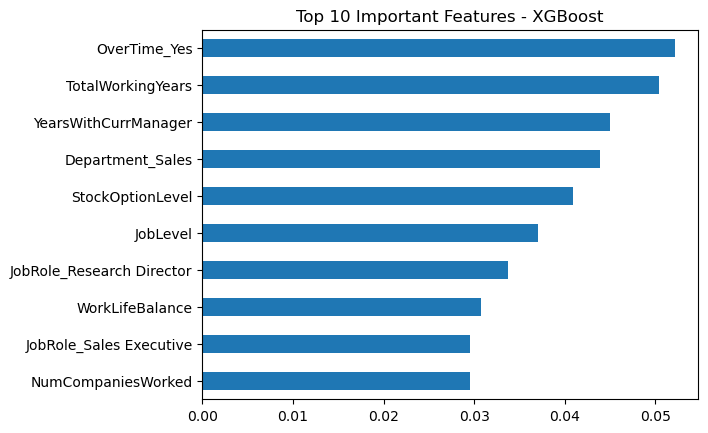

In [36]:
# Get feature importance 
importances = xgb_model.feature_importances_

# Feature names
feature_names = X.columns

# Create series
feat_imp = pd.Series(importances, index=feature_names)

# Sort and take top 10
feat_imp = feat_imp.sort_values(ascending=False).head(10)

# Plot
plt.figure()
feat_imp.plot(kind="barh")
plt.title("Top 10 Important Features - XGBoost")
plt.gca().invert_yaxis()
plt.savefig("results/figures/xgboost_feature_importance.png", bbox_inches="tight")
plt.show()

# IMPLEMENTING SHAP FOR EXPLAINABILITY

In [37]:
import shap
shap.initjs()

# Get the feature names
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# Initilize explainer
explainer = shap.TreeExplainer(xgb_model)

# Compute shap value
shap_values = explainer.shap_values(X_test)

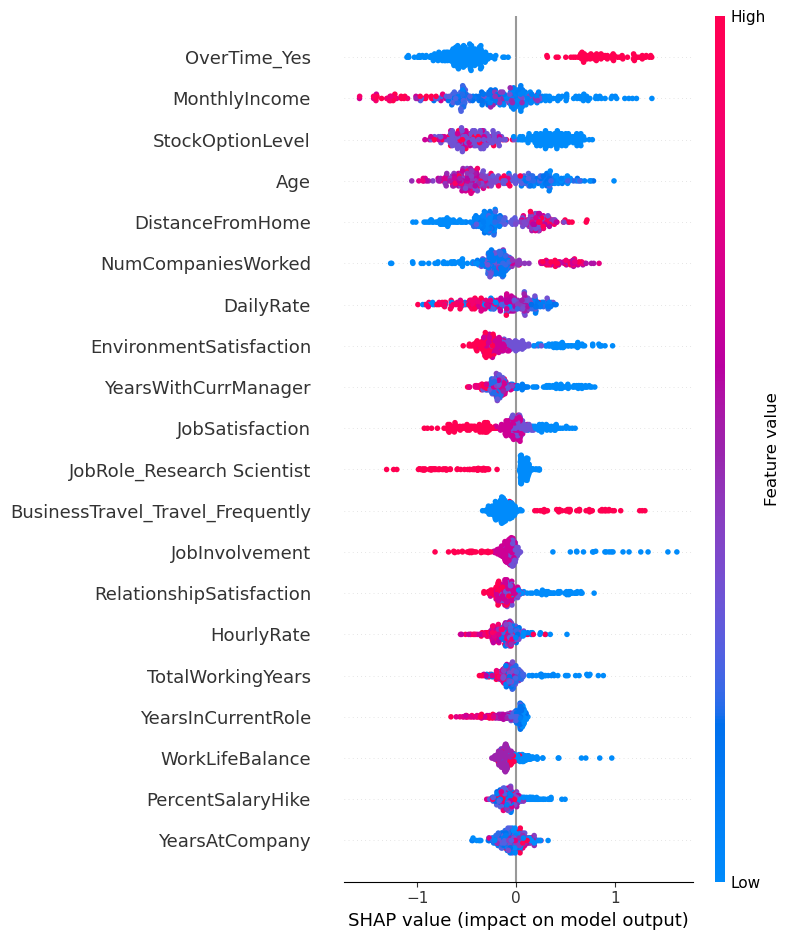

In [38]:
# Shap summary
shap.summary_plot(shap_values, X_test_df, show=False)
plt.savefig("results/figures/shap_summary_plot.png", bbox_inches="tight")
plt.show()

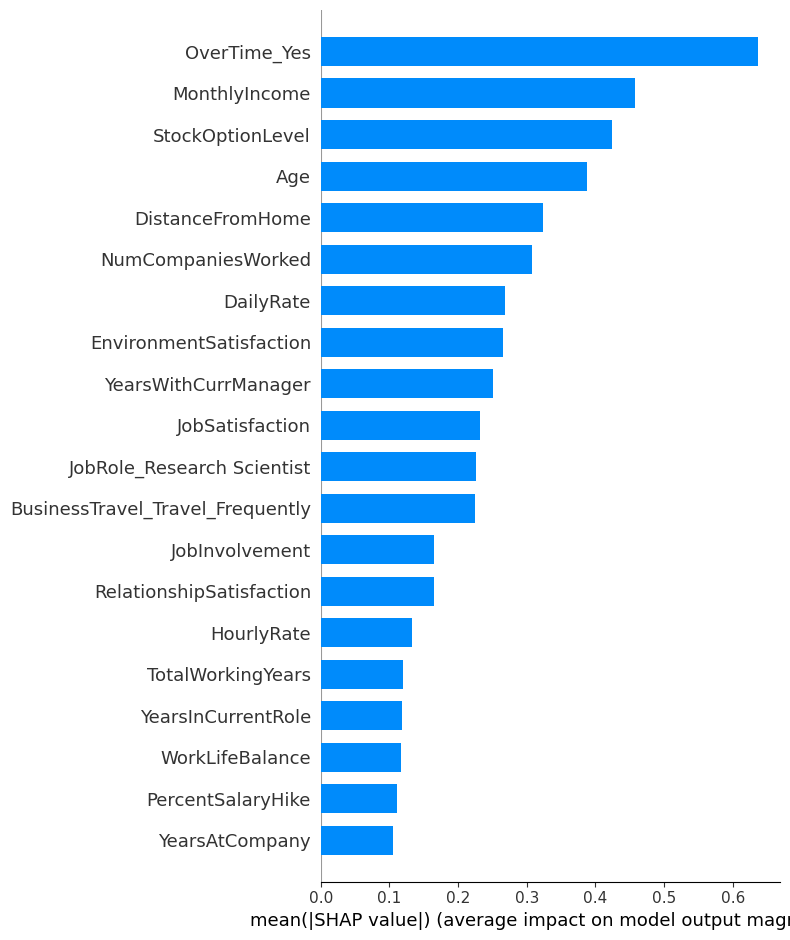

In [39]:
# Bar plot
shap.summary_plot(shap_values, X_test_df, plot_type = "bar", show=False)
plt.savefig("results/figures/shap_bar_plot.png", bbox_inches="tight")
plt.show()

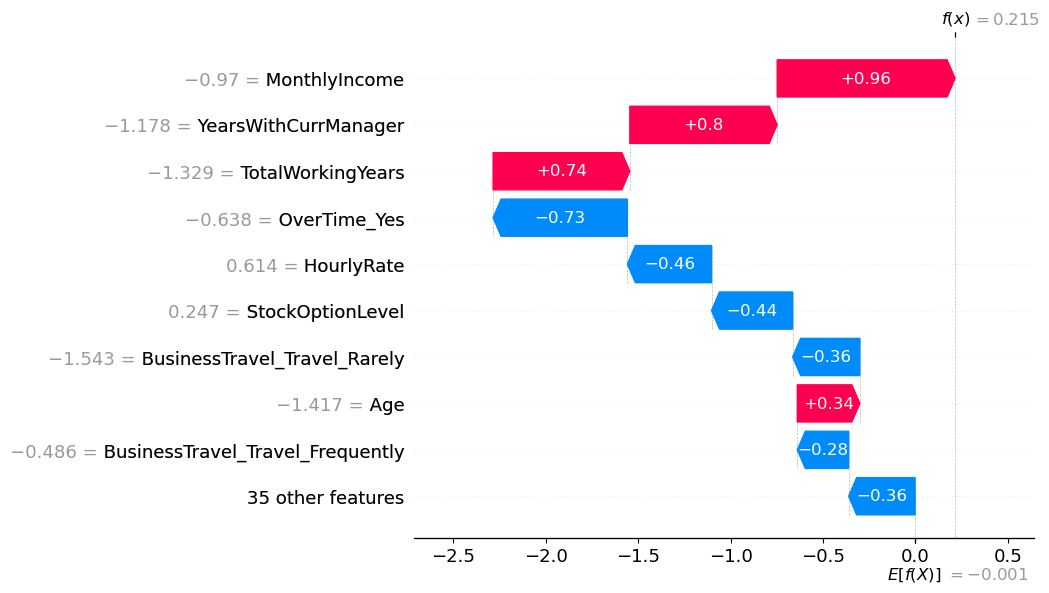

In [40]:
# Individual explanation
shap.plots.waterfall(shap.Explanation(values = shap_values[0], base_values=explainer.expected_value, data=X_test_df.iloc[0], feature_names=X_test_df.columns),show=False)
plt.savefig("results/figures/shap_waterfall.png", bbox_inches=False)
plt.show()

# MODEL STABILITY - CROSS-VALIDATION

In [41]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

In [42]:
# Cross-validation with logistic regression
log_model = LogisticRegression(max_iter=1000)

#Accuracy
log_acc = cross_val_score(log_model, X, y, cv=cv, scoring='accuracy')

#ROC-AUC
log_auc = cross_val_score(log_model, X, y, cv=cv, scoring='roc_auc')

print("Logistic Regression")
print("Accuracy: ", log_acc.mean(), "+/-", log_acc.std())
print("ROC-AUC: ", log_auc.mean(), "+/-", log_auc.std())

/home/jmozebo/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/jmozebo/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproces

Logistic Regression
Accuracy:  0.8612244897959183 +/- 0.01449474540997448
ROC-AUC:  0.7764431130668875 +/- 0.022968875239903597


/home/jmozebo/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
xgb_model = XGBClassifier(scale_pos_weight = 1233/237, n_estimators = 200, learning_rate = 0.05, max_depth = 5, random_state = 42)

# Accuracy
xgb_acc = cross_val_score(xgb_model, X, y, cv=cv, scoring='accuracy')

# ROC-AUC
xgb_auc = cross_val_score(xgb_model, X, y, cv=cv, scoring='roc_auc')

print("\nXGBoost")
print("Accuracy: ", xgb_acc.mean(), "+/-", xgb_acc.std())
print("ROC-AUC: ", xgb_auc.mean(), "+/-", xgb_auc.std())


XGBoost
Accuracy:  0.8496598639455784 +/- 0.012054452480727422
ROC-AUC:  0.7975332164489705 +/- 0.010889783435566845
